In [ ]:
# NumPy para manejo de vectores
import numpy as np

# Matplotlib para visualizar embeddings
import matplotlib.pyplot as plt

# Gensim (modelos de word embeddings)
import gensim
import gensim.downloader as api
from gensim.models.fasttext import load_facebook_model
from gensim.models import Word2Vec

# NLTK
import nltk
from nltk.tokenize import regexp_tokenize
from nltk.corpus import gutenberg

# SpaCy
import spacy

# Sci-kit learn
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

english_sw = set(nltk.corpus.stopwords.words("english"))

In [2]:
for model_name in gensim_api.info()["models"].keys():
    print(model_name)

fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
__testing_word2vec-matrix-synopsis


# Ejercicio 1
- Los modelos basados en embeddings estáticos proporcionan una representación
vectorial de palabras en un espacio continuo de dimensiones fijas, donde cada palabra
tiene un único vector asociado independientemente del contexto en el que aparezca.
Estos modelos son capaces de capturar la semántica de las palabras a partir de su
entrenamiento no supervisado sobre grandes corpus de texto.  

    Word2Vec es uno de los modelos que aprende estas representaciones vectoriales
    mediante el entrenamiento sobre ventanas de contexto. En concreto, emplea la técnica
    Skip-gram, que predice palabras de contexto a partir de una palabra objetivo, o CBOW,
    que predice la palabra objetivo a partir de su contexto.  

    Por otro lado, GloVe es otro de los modelos para la generación de embeddings estáticos,
    basándose para ello en el análisis de coocurrencias de palabras. Específicamente, GloVe
    basa su entrenamiento en la construcción de una matriz de coocurrencia de palabras,
    factorizándola para la obtención de representaciones vectoriales.  

    Asimismo, otro modelo relevante para la generación de estos embeddings es FastText.
    A diferencia de Word2Vec y Glove, FastText no trabaja con palabras individuales, sino
    que lo hace a nivel de subpalabra o n-gramas de carácteres. Esta representación permite
    una mayor robustez ante palabras infrecuentes o con errores tipográficos, solucionando
    el famoso problema de palabras fuera del vocabulario (OOV por sus siglas en inglés).  

    En este ejercicio, se desea explorar el uso de los modelos de embeddings estáticos de
    palabras Word2Vec, GloVe y FastText para el análisis de relaciones semánticas. Una
    propiedad interesante de estos modelos es su capacidad para capturar relaciones
    semánticamente analógicas, como las presentes en la famosa ecuación:  
    $$
    \text{king} - \text{man} + \text{woman} = \text{queen}
    $$

In [11]:
glove = api.load('glove-wiki-gigaword-50')


[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
pos=["king","woman"]
neg=["man"]
most_similar_glove= glove.most_similar(positive=pos, negative=neg, topn=1)
print(most_similar_glove)


[('queen', 0.8523604273796082)]


---
# Ejercicio 2
- Tanto Word2Vec como GloVe y FastText proporcionan embedding estáticos a nivel de palabra. Dada una lista de palabras, podemos obtener una matriz de embeddings, donde las filas son las palabras que componen la lista y las columnas son el número de dimensiones que tienen los embeddings.  

    - Con Word2Vec, GloVe y FastText, obtén la matriz de embeddings del conjunto de palabras ["apple", "orange", "banana"]. ¿Qué dimensiones tienen? ¿Qué características tienen dichas matrices (dispersa vs densa, números enteros vs flotantes, …)?
    - Con Word2Vec, GloVe y FastText, intenta obtener el embedding de la palabra "orangge". ¿Qué modelos permiten obtenerlo? ¿Cuáles no? ¿A qué se debe?

In [ ]:
words = ["apple", "orange", "banana"]
word_vectors = glove[words]


embeddings_matrix = np.array(word_vectors)

print("Dimensión matriz:", embeddings_matrix.shape)



Dimensión matriz: (3, 50)


Se trata de una matriz densa (casi todas distintas de 0) (no es dispersa como BoW, por ejemplo).
Tamaño en este caso dimensión (3,50) de floats.

In [24]:
#Da error, FastText sí soportaría "orangge" pero GloVe no
orangge_vector = glove["orangge"]
print("Dimensión vector:", orangge_vector)

KeyError: "Key 'orangge' not present"

---
# Ejercicio 3
- A través del algoritmo de reducción de dimensionalidad PCA se puede visualizar gráficamente el espacio de embeddings representado por estos modelos. A continuación, se muestra un código de ejemplo que permite visualizar un conjunto de palabras words dados sus correspondientes embeddings.

- Emplea Word2Vec, GloVe y FastText para obtener los embeddings de la lista de 
palabras ["woman", "king", "man", "queen"]. Aplica PCA sobre estos embeddings 
y represéntalos gráficamente con Matplotlib. ¿Qué palabras se muestran cerca? 
- Emplea Word2Vec, GloVe y FastText para obtener los embeddings de la nueva 
lista de palabras ["woman", "king", "man", "queen", "potato", "carrot", 
"tomato"]. Aplica PCA sobre estos embeddings y represéntalos gráficamente con 
Matplotlib. ¿Qué palabras se muestran cerca en esta ocasión? 
 
 
 


In [34]:
palabras= ["woman", "king", "man", "queen"]
vector_palabras = glove[palabras]
embeddings_1 = np.array(vector_palabras)


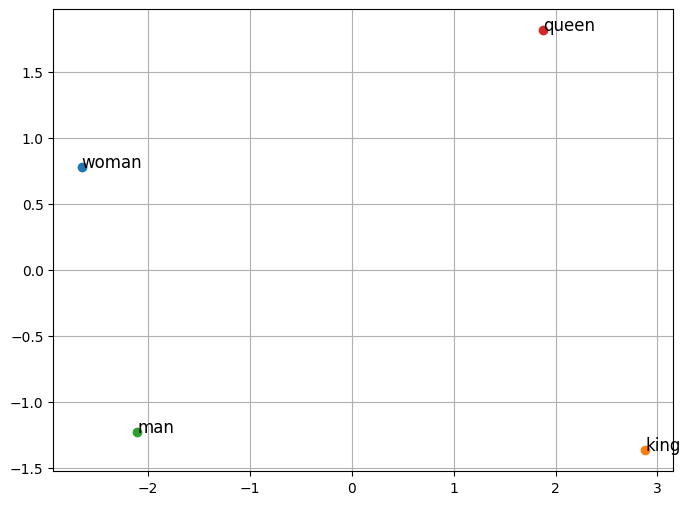

In [35]:
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA 
 
pca = PCA(n_components=2) 
word_vectors_2d = pca.fit_transform(embeddings_1) 
plt.figure(figsize=(8, 6)) 
 
for word, coord in zip(palabras, word_vectors_2d): 
   plt.scatter(coord[0], coord[1], marker='o', label=word) 
   plt.text(coord[0], coord[1], word, fontsize=12) 
 
plt.grid() 
plt.show() 
 


In [37]:
palabras2= ["woman", "king", "man", "queen", "potato", "carrot", "tomato"]
vector_palabras2 = glove[palabras2]
embeddings_2 = np.array(vector_palabras2)

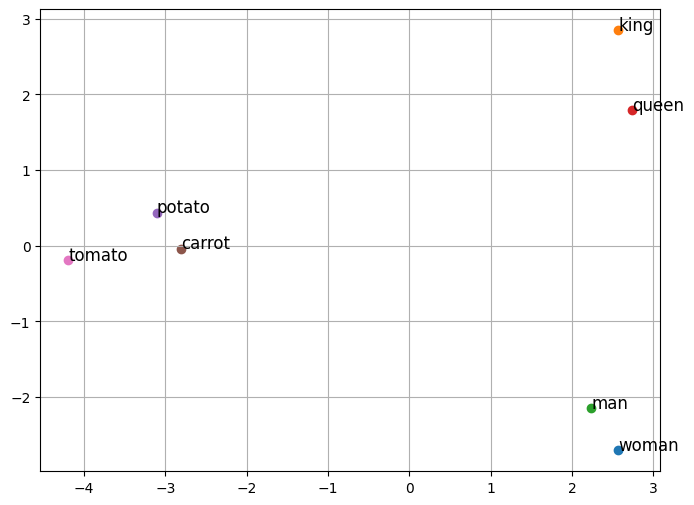

In [38]:
#Aplicar PCA
pca = PCA(n_components=2)
word_vectors_2d_2 = pca.fit_transform(embeddings_2)
plt.figure(figsize=(8, 6))
for word, coord in zip(palabras2, word_vectors_2d_2):
    plt.scatter(coord[0], coord[1], marker='o', label=word)
    plt.text(coord[0], coord[1], word, fontsize=12)
plt.grid()
plt.show()  

---
# Ejercicio 4
- Aunque Word2Vec, GloVe y FastText proporcionan embeddings estáticos a nivel de palabra, existen diferentes técnicas para obtener embeddings a nivel de frase. Una de las formas más populares consiste en calcular la media de embeddings de los diferentes tokens que componen una frase.

Otra estrategia también frecuente consiste en quedarse con el máximo de cada dimensión, resaltando las características más sobresalientes de cada token analizado. 

Dada la frase de consulta "Dogs are domestic animals." y el conjunto de frases ["Dogs are pets.", "This is a dog.", "They are free today."]
Tokeniza las anteriores frases y elimina stopwords y puntuación. 
    - Con Word2Vec, GloVe y FastText, obtén el vector promedio y el vector máximo de la frase de consulta y el conjunto de frases.
    - Con Word2Vec, GloVe y FastText, obtén el vector de media ponderada por IDF. Para ello, construye un diccionario de (palabras, su valor de idf).
    - Calcula la similitud coseno entre la frase de consulta y cada frase del conjunto de frases usando los anteriores vectores. Reflexiona sobre qué frases son consideradas más similares por estos modelos y qué vectores funcionan mejor (media, máximo, o media ponderada por IDF).

In [40]:
from nltk.tokenize import WordPunctTokenizer, PunktSentenceTokenizer
from nltk.corpus import stopwords

from sklearn.metrics.pairwise import cosine_similarity

In [47]:
frase="Dogs are domestic animals." 
doc= ["Dogs are pets.", "This is a dog.", "They are free today."]

stop_words = set(stopwords.words('english'))
tokenizer = WordPunctTokenizer()
def tokenize_and_remove_stopwords(text):
    tokens = tokenizer.tokenize(text.lower())
    return [token for token in tokens if token.isalpha() and token not in stop_words]
frase_tokens = tokenize_and_remove_stopwords(frase)
doc_tokens = [tokenize_and_remove_stopwords(d) for d in doc]

# Con Word2Vec, GloVe y FastText, obtén el vector promedio y el vector máximo de la frase de consulta y el conjunto de frases.
def get_average_vector(tokens, model):
    vectors = [model[token] for token in tokens if token in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0) 

def get_max_vector(tokens, model):
    vectors = [model[token] for token in tokens if token in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.max(vectors, axis=0)

def get_weighted_average_vector(tokens, model, idf_dict):
    vectors = [model[token] * idf_dict.get(token, 0) for token in tokens if token in model]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.sum(vectors, axis=0) / np.sum([idf_dict.get(token, 0) for token in tokens if token in model]) 

# Construir un diccionario de (palabras, su valor de idf)
def compute_idf(corpus):
    n_docs = len(corpus)
    idf_dict = {}
    for doc in corpus:
        tokens = set(tokenize_and_remove_stopwords(doc))
        for token in tokens:
            if token not in idf_dict:
                idf_dict[token] = 0
            idf_dict[token] += 1
    for token in idf_dict:
        idf_dict[token] = np.log(n_docs / (idf_dict[token] + 1))  # +1 para evitar división por cero
    return idf_dict 

idf_dict = compute_idf([frase] + doc)
# Obtener los vectores promedio, máximo y ponderado por IDF
average_vector_frase = get_average_vector(frase_tokens, glove)
max_vector_frase = get_max_vector(frase_tokens, glove)
weighted_average_vector_frase = get_weighted_average_vector(frase_tokens, glove, idf_dict)  
average_vectors_docs = [get_average_vector(tokens, glove) for tokens in doc_tokens]
max_vectors_docs = [get_max_vector(tokens, glove) for tokens in doc_tokens]
weighted_average_vectors_docs = [get_weighted_average_vector(tokens, glove, idf_dict) for tokens in doc_tokens] 
# Calcular la similitud coseno entre la frase de consulta y cada frase del conjunto de frases usando los anteriores vectores
cosine_similarities_average = cosine_similarity([average_vector_frase], average_vectors_docs)[0]
cosine_similarities_max = cosine_similarity([max_vector_frase], max_vectors_docs)[0]
cosine_similarities_weighted_average = cosine_similarity([weighted_average_vector_frase], weighted_average_vectors_docs)[0]
# Imprimir los resultados
print("Similitud coseno (promedio):", cosine_similarities_average)
print("Similitud coseno (máximo):", cosine_similarities_max)
print("Similitud coseno (promedio ponderado por IDF):", cosine_similarities_weighted_average)           



Similitud coseno (promedio): [0.85422593 0.7252621  0.59236807]
Similitud coseno (máximo): [0.76284873 0.5211921  0.69272435]
Similitud coseno (promedio ponderado por IDF): [0.7658709 0.6564507 0.6177348]


---
# Ejercicio 5
- Se plantea un ejercicio para entrenar un modelo de embeddings desde cero. En este caso, se van a seleccionar los tres libros de Jane Austen que están disponibles en el proyecto Gutenberg en NLTK.

- Los pasos a seguir son los siguientes:
    - Coger el texto de los tres libros.
    - Hacer un pre-procesamiento de los textos utilizando SpaCy.
        - Convertir tokens a minúsculas.
        - Eliminar tokens que no sean palabras.
    - Cargar el modelo de Word2Vec.
    - Entrenar el modelo.

In [ ]:
import spacy
from gensim.models import Word2Vec 
#Por simplificar usamos un corpus pequeño
corpus = [
    "The dog loves the cat.",
    "The cat sleeps on the sofa.",
    "The dog barks loudly.",
    "Dogs and cats are good pets.",
    "The sofa is comfortable."
]

# Tokenizar y eliminar stopwords
nlp = spacy.load("en_core_web_sm")
def tokenize_and_remove_stopwords_spacy(text):
    doc = nlp(text)
    return [token.text for token in doc if not token.is_stop and not token.is_punct]
tokenized_corpus = [tokenize_and_remove_stopwords_spacy(text) for text in corpus]   
    
model= Word2Vec(sentences=tokenized_corpus, vector_size=50, window=5, min_count=1, sg=1) # sg=1 para Skip-gram, sg=0 para CBOW (si fuera texto grande)




In [53]:

print(model.wv.most_similar('loves'))
print(model.wv.similarity('dog', 'cat'))


[('good', 0.1977662444114685), ('sofa', 0.16704078018665314), ('dog', 0.1551763266324997), ('Dogs', 0.09591114521026611), ('sleeps', 0.06516239047050476), ('cats', 0.06109792739152908), ('barks', 0.058373648673295975), ('loudly', 0.04555804654955864), ('pets', -0.03871109336614609), ('comfortable', -0.09488880634307861)]
0.011071963


Una vez hecho todo lo anterior, se pide lo siguiente: 
1. Sacar estadísticas del modelo (dimensión de los vectores y número de palabras).  
2. Mostrar las palabras más similares a ‘love’. 
3. Mostrar las palabras más similares a ‘hate’. 
4. Mostrar la similitud entre las palabras ‘love’ y ‘art’. 
5. ¿Y si miramos una palabra que no esté seguro en el vocabulario? Por ejemplo, 
buscar las palabras más similares a ‘pianista’. 
6. Buscar analogías entre  
 
love- hate + heart = ¿? 
Entonces, a la hora de buscar las palabras similares hay que indicar las palabras 
positivas (‘love’ y ‘heart’ en este caso) y negativas (‘hate’ en este caso).